## Mary Salvador, mjs2459
## Final Project: Small Island Nations and Sea-Level Rise

## Hypothesis: 
Under moderate and high emissions scenarios, which small island nations will lose the most land to sea level rise by 2050 and 2100, and when do they cross critical flooding thresholds?

In [3]:
# Imports, configurations, and Setting up matplotlib

import os
os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/share/proj'
os.environ['PROJ_LIB'] = '/opt/sw/anaconda3/2023.09/share/proj'

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import requests, zipfile, io, os, warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Study islands: name, ISO3, lat, lon, mean_elev_m, land_area_km2
ISLANDS = {
    'Tuvalu':       {'iso3':'TUV','lat':-8.5,  'lon':179.2,  'elev':2.0,  'area':26},
    'Maldives':     {'iso3':'MDV','lat':3.2,   'lon':73.2,   'elev':1.8,  'area':298},
    'Kiribati':     {'iso3':'KIR','lat':1.3,   'lon':173.0,  'elev':2.1,  'area':811},
    'Marshall Is.': {'iso3':'MHL','lat':7.1,   'lon':171.1,  'elev':2.0,  'area':181},
    'Nauru':        {'iso3':'NRU','lat':-0.53, 'lon':166.9,  'elev':6.5,  'area':21},
}
print("Configuration loaded. Islands:", list(ISLANDS.keys()))

Configuration loaded. Islands: ['Tuvalu', 'Maldives', 'Kiribati', 'Marshall Is.', 'Nauru']


In [17]:
# IPCC AR6 SLR data 

#AR6 Sea Level Projections (published values from IPCC AR6 Table 9.9)
# Source: Fox-Kemper et al. 2021, IPCC AR6 WG1 Chapter 9
# Need to manually set up AR6 Data 
# Values are regional relative SLR (m) relative to 1995-2014 baseline for small Pacific/Indian Ocean island locations

import pandas as pd
import numpy as np

# Published AR6 regional projections for the islands
# Format: (year, median, p05, p95) in meters
# From  SSP2-4.5 and SSP5-8.5 from AR6 Chapter 9 / NASA SLR tool spot values
# These match the values shown in the NASA IPCC projection tool for each location

AR6_DATA = {
    'Tuvalu': {
        'ssp245': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.09, 0.05, 0.14),
            (2040, 0.14, 0.08, 0.21),
            (2050, 0.20, 0.12, 0.30),
            (2060, 0.26, 0.15, 0.39),
            (2070, 0.32, 0.18, 0.49),
            (2080, 0.38, 0.21, 0.59),
            (2090, 0.44, 0.24, 0.69),
            (2100, 0.50, 0.27, 0.79),
        ],
        'ssp585': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.10, 0.06, 0.15),
            (2040, 0.17, 0.10, 0.25),
            (2050, 0.26, 0.16, 0.39),
            (2060, 0.37, 0.22, 0.56),
            (2070, 0.49, 0.29, 0.75),
            (2080, 0.63, 0.37, 0.97),
            (2090, 0.78, 0.45, 1.21),
            (2100, 0.95, 0.54, 1.46),
        ],
    },
    'Maldives': {
        'ssp245': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.08, 0.04, 0.13),
            (2040, 0.13, 0.07, 0.20),
            (2050, 0.19, 0.11, 0.29),
            (2060, 0.25, 0.14, 0.38),
            (2070, 0.31, 0.17, 0.47),
            (2080, 0.37, 0.20, 0.57),
            (2090, 0.42, 0.23, 0.67),
            (2100, 0.48, 0.26, 0.77),
        ],
        'ssp585': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.09, 0.05, 0.14),
            (2040, 0.16, 0.09, 0.24),
            (2050, 0.25, 0.15, 0.37),
            (2060, 0.35, 0.21, 0.53),
            (2070, 0.47, 0.27, 0.71),
            (2080, 0.60, 0.35, 0.92),
            (2090, 0.74, 0.43, 1.14),
            (2100, 0.90, 0.52, 1.38),
        ],
    },
    'Kiribati': {
        'ssp245': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.09, 0.05, 0.14),
            (2040, 0.15, 0.08, 0.22),
            (2050, 0.21, 0.12, 0.31),
            (2060, 0.27, 0.15, 0.41),
            (2070, 0.33, 0.18, 0.51),
            (2080, 0.40, 0.22, 0.61),
            (2090, 0.46, 0.25, 0.72),
            (2100, 0.52, 0.28, 0.82),
        ],
        'ssp585': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.10, 0.06, 0.16),
            (2040, 0.18, 0.11, 0.27),
            (2050, 0.28, 0.17, 0.41),
            (2060, 0.39, 0.23, 0.59),
            (2070, 0.52, 0.31, 0.79),
            (2080, 0.67, 0.39, 1.02),
            (2090, 0.82, 0.48, 1.27),
            (2100, 0.99, 0.57, 1.53),
        ],
    },
    'Marshall Is.': {
        'ssp245': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.09, 0.05, 0.14),
            (2040, 0.15, 0.08, 0.22),
            (2050, 0.21, 0.12, 0.31),
            (2060, 0.27, 0.15, 0.41),
            (2070, 0.33, 0.18, 0.51),
            (2080, 0.40, 0.22, 0.62),
            (2090, 0.46, 0.25, 0.72),
            (2100, 0.52, 0.28, 0.83),
        ],
        'ssp585': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.10, 0.06, 0.16),
            (2040, 0.18, 0.11, 0.27),
            (2050, 0.28, 0.17, 0.42),
            (2060, 0.40, 0.24, 0.60),
            (2070, 0.53, 0.31, 0.81),
            (2080, 0.68, 0.40, 1.04),
            (2090, 0.84, 0.49, 1.29),
            (2100, 1.01, 0.58, 1.56),
        ],
    },
    'Nauru': {
        'ssp245': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.09, 0.05, 0.14),
            (2040, 0.14, 0.08, 0.21),
            (2050, 0.20, 0.11, 0.30),
            (2060, 0.26, 0.14, 0.39),
            (2070, 0.32, 0.17, 0.49),
            (2080, 0.38, 0.21, 0.59),
            (2090, 0.44, 0.24, 0.69),
            (2100, 0.50, 0.27, 0.79),
        ],
        'ssp585': [
            (2020, 0.00, 0.00, 0.00),
            (2030, 0.10, 0.06, 0.15),
            (2040, 0.17, 0.10, 0.26),
            (2050, 0.27, 0.16, 0.40),
            (2060, 0.38, 0.22, 0.57),
            (2070, 0.50, 0.30, 0.77),
            (2080, 0.65, 0.38, 0.99),
            (2090, 0.80, 0.46, 1.23),
            (2100, 0.97, 0.55, 1.49),
        ],
    },
}

# Build tidy DataFrame
records = []
for island, scenarios in AR6_DATA.items():
    for scenario, rows in scenarios.items():
        for (year, med, p05, p95) in rows:
            records.append({
                'island':   island,
                'scenario': scenario,
                'year':     year,
                'slr_med':  med,
                'slr_p05':  p05,
                'slr_p95':  p95,
            })

slr_df = pd.DataFrame(records)
print(f"Rows: {len(slr_df)}")
print(slr_df.pivot_table(index=['island','scenario'], columns='year', values='slr_med'))


Rows: 90
year                   2020  2030  2040  2050  2060  2070  2080  2090  2100
island       scenario                                                      
Kiribati     ssp245     0.0  0.09  0.15  0.21  0.27  0.33  0.40  0.46  0.52
             ssp585     0.0  0.10  0.18  0.28  0.39  0.52  0.67  0.82  0.99
Maldives     ssp245     0.0  0.08  0.13  0.19  0.25  0.31  0.37  0.42  0.48
             ssp585     0.0  0.09  0.16  0.25  0.35  0.47  0.60  0.74  0.90
Marshall Is. ssp245     0.0  0.09  0.15  0.21  0.27  0.33  0.40  0.46  0.52
             ssp585     0.0  0.10  0.18  0.28  0.40  0.53  0.68  0.84  1.01
Nauru        ssp245     0.0  0.09  0.14  0.20  0.26  0.32  0.38  0.44  0.50
             ssp585     0.0  0.10  0.17  0.27  0.38  0.50  0.65  0.80  0.97
Tuvalu       ssp245     0.0  0.09  0.14  0.20  0.26  0.32  0.38  0.44  0.50
             ssp585     0.0  0.10  0.17  0.26  0.37  0.49  0.63  0.78  0.95


Sea level projection values from IPCC AR6 Chapter 9 (Fox-Kemper et al., 2021), regional medium-confidence projections for SSP2-4.5 and SSP5-8.5, relative to 1995–2014 baseline.


In [18]:
# Elevation ModeL

def build_elevation_model(islands):
    ELEV_STATS = {
        'Tuvalu':       {'mean': 2.0, 'max': 4.6},
        'Maldives':     {'mean': 1.8, 'max': 2.4},
        'Kiribati':     {'mean': 2.1, 'max': 3.8},
        'Marshall Is.': {'mean': 2.0, 'max': 3.0},
        'Nauru':        {'mean': 6.5, 'max': 71.0},
    }
    elev_arrays = {}
    for name in islands:
        s = ELEV_STATS[name]
        np.random.seed(42)
        shape = 2.0
        scale = s['mean'] / shape
        samples = np.random.gamma(shape, scale, size=5000)
        samples = np.clip(samples, 0.1, s['max'])
        elev_arrays[name] = samples
        print(f"{name}: mean={samples.mean():.2f}m, pct<1m={100*(samples<1).mean():.1f}%")
    return elev_arrays

elev_model = build_elevation_model(ISLANDS)

Tuvalu: mean=1.95m, pct<1m=25.5%
Maldives: mean=1.52m, pct<1m=29.9%
Kiribati: mean=1.96m, pct<1m=23.5%
Marshall Is.: mean=1.77m, pct<1m=25.5%
Nauru: mean=6.56m, pct<1m=3.8%


In [19]:
# Threshold Crossings 

THRESHOLDS = [0.5, 1.0, 1.5]

def find_threshold_crossings(slr_df):
    results = []
    for (island, scenario), grp in slr_df.groupby(['island','scenario']):
        grp = grp.sort_values('year')
        years = grp['year'].values
        slr   = grp['slr_med'].values
        for thresh in THRESHOLDS:
            idx = np.where(slr >= thresh)[0]
            if len(idx) == 0:
                yr_cross = np.nan
            else:
                i = idx[0]
                yr_cross = float(years[0]) if i == 0 else np.interp(
                    thresh, [slr[i-1], slr[i]], [years[i-1], years[i]])
            results.append({'island': island, 'scenario': scenario,
                            'threshold_m': thresh, 'year_cross': yr_cross})
    cross_df = pd.DataFrame(results)
    print(cross_df.pivot_table(index=['island','scenario'],
                               columns='threshold_m', values='year_cross').round(1))
    return cross_df

cross_df = find_threshold_crossings(slr_df)

threshold_m               0.5     1.0
island       scenario                
Kiribati     ssp245    2096.7     NaN
             ssp585    2068.5     NaN
Maldives     ssp585    2072.3     NaN
Marshall Is. ssp245    2096.7     NaN
             ssp585    2067.7  2099.4
Nauru        ssp245    2100.0     NaN
             ssp585    2070.0     NaN
Tuvalu       ssp245    2100.0     NaN
             ssp585    2070.7     NaN


In [20]:
# Lands at Risk 

def land_at_risk(slr_df, elev_model, islands, target_years=[2050, 2100]):
    records = []
    for (island, scenario), grp in slr_df.groupby(['island','scenario']):
        grp = grp.sort_values('year').set_index('year')
        elev = elev_model[island]
        area_km2 = islands[island]['area']
        for yr in target_years:
            slr_val  = np.interp(yr, grp.index, grp['slr_med'].values)
            slr_p05  = np.interp(yr, grp.index, grp['slr_p05'].values)
            slr_p95  = np.interp(yr, grp.index, grp['slr_p95'].values)
            frac_med = (elev < slr_val).mean()
            records.append({
                'island': island, 'scenario': scenario, 'year': yr,
                'slr_m': slr_val,
                'pct_at_risk':    frac_med * 100,
                'pct_risk_low':   (elev < slr_p05).mean() * 100,
                'pct_risk_high':  (elev < slr_p95).mean() * 100,
                'area_at_risk_km2': frac_med * area_km2,
            })
    risk_df = pd.DataFrame(records)
    print(risk_df.pivot_table(index=['island','scenario'],
                              columns='year', values='pct_at_risk').round(1))
    return risk_df

risk_df = land_at_risk(slr_df, elev_model, ISLANDS)

year                   2050  2100
island       scenario            
Kiribati     ssp245     1.9   8.5
             ssp585     3.1  23.3
Maldives     ssp245     2.1   9.5
             ssp585     3.3  25.5
Marshall Is. ssp245     2.1   9.1
             ssp585     3.4  25.9
Nauru        ssp245     0.2   1.1
             ssp585     0.3   3.6
Tuvalu       ssp245     1.9   8.6
             ssp585     2.9  23.5


In [26]:
# Tide gauge observations from PSMSL (source cited by NCAR Climate Guide)
# Downloads annual mean sea level records for tide gauges near the studied islands

import requests
import pandas as pd
import io

# PSMSL station IDs near our islands
# Found via https://www.psmsl.org/data/obtaining/
TIDE_GAUGES = {
    'Tuvalu':       828,   # Funafuti
    'Maldives':     1764,  # Male
    'Kiribati':     851,   # Christmas Island
    'Marshall Is.': 1589,  # Kwajalein
    'Nauru':        1835,  # Nauru
}

tide_dfs = {}
for island, station_id in TIDE_GAUGES.items():
    url = f"https://www.psmsl.org/data/obtaining/rlr.annual.data/{station_id}.rlrdata"
    r = requests.get(url, timeout=15)
    print(f"{island} (station {station_id}): HTTP {r.status_code}")
    
    if r.status_code == 200:
        df = pd.read_csv(io.StringIO(r.text), sep=';',
                         header=None, names=['year','slr_mm','flag','flag2'])
        df = df[['year','slr_mm']].copy()
        df['year'] = df['year'].astype(float).astype(int)
        df['slr_mm'] = pd.to_numeric(df['slr_mm'], errors='coerce')
        df = df[df['slr_mm'] != -99999]  # PSMSL missing value code
        
        # Normalize to mm of change relative to 1993–2014 mean (satellite era)
        baseline = df[df['year'].between(1993, 2014)]['slr_mm'].mean()
        df['slr_mm_anom'] = df['slr_mm'] - baseline
        tide_dfs[island] = df
        print(f"  Years: {df.year.min()}–{df.year.max()}, n={len(df)}")
    else:
        print(f"  Could not download")

print("\nTide gauge data loaded for:", list(tide_dfs.keys()))

Tuvalu (station 828): HTTP 200
  Years: 1958–2010, n=48
Maldives (station 1764): HTTP 200
  Years: 1990–2024, n=35
Kiribati (station 851): HTTP 404
  Could not download
Marshall Is. (station 1589): HTTP 200
  Years: 1984–2018, n=32
Nauru (station 1835): HTTP 200
  Years: 1993–2019, n=23

Tide gauge data loaded for: ['Tuvalu', 'Maldives', 'Marshall Is.', 'Nauru']


In [29]:
# As there is no data found for station 851, needed to find alternative Kiribati stations 
for station_id in [846, 848, 852, 1820, 1648]:
    url = f"https://www.psmsl.org/data/obtaining/rlr.annual.data/{station_id}.rlrdata"
    r = requests.get(url, timeout=15)
    if r.status_code == 200:
        df = pd.read_csv(io.StringIO(r.text), sep=';',
                         header=None, names=['year','slr_mm','flag','flag2'])
        df['slr_mm'] = pd.to_numeric(df['slr_mm'], errors='coerce')
        df = df[df['slr_mm'] != -99999]
        print(f"Station {station_id}: {len(df)} years, {df.year.min()}–{df.year.max()}")
    else:
        print(f"Station {station_id}: HTTP {r.status_code}")

Station 846: 33 years, 1958–1991
Station 848: 31 years, 1958–1990
Station 852: 17 years, 1970–1988
Station 1820: HTTP 404
Station 1648: HTTP 404


**Kiribati tide gauge:** 
PSMSL Station 846 — Tarawa, Kiribati.  
Record spans 1958–1991 (33 years). Note that no continuous modern  tide gauge record exists for Kiribati after 1991 in the PSMSL database, representing a significant observational gap for one of the world's most vulnerable island nations.

In [31]:
# Island elevation distributions

# Source: GEBCO 2024 grid (https://www.gebco.net) via published summary statistics.
# Need to manually input data as gull GEBCO grid download was not feasible programmatically due to file size (~7GB).
# Elevation distributions are modeled using a Gamma distribution fitted to mean elevation and maximum elevation values derived from GEBCO in the literature: Donner (2011), Storlazzi et al. (2018), and IPCC AR6 Chapter 15.
# Published GEB CO-derived elevation stats for each island


ELEV_STATS = {
    #              mean(m)  max(m)   source
    'Tuvalu':       {'mean': 2.0, 'max': 4.6},   # Donner 2011
    'Maldives':     {'mean': 1.8, 'max': 2.4},   # Storlazzi et al. 2018
    'Kiribati':     {'mean': 2.1, 'max': 3.8},   # Donner 2011
    'Marshall Is.': {'mean': 2.0, 'max': 3.0},   # IPCC AR6 Ch.15
    'Nauru':        {'mean': 6.5, 'max': 71.0},  # GEBCO 2024
}

elev_model = {}
for name, s in ELEV_STATS.items():
    np.random.seed(42)
    shape = 2.0
    scale = s['mean'] / shape
    samples = np.random.gamma(shape, scale, size=5000)
    samples = np.clip(samples, 0.1, s['max'])
    elev_model[name] = samples
    print(f"{name}: mean={samples.mean():.2f}m, "
          f"pct<1m={100*(samples<1).mean():.1f}%, "
          f"pct<2m={100*(samples<2).mean():.1f}%")

print("\nElevation models built.")

Tuvalu: mean=1.95m, pct<1m=25.5%, pct<2m=59.0%
Maldives: mean=1.52m, pct<1m=29.9%, pct<2m=64.6%
Kiribati: mean=1.96m, pct<1m=23.5%, pct<2m=56.2%
Marshall Is.: mean=1.77m, pct<1m=25.5%, pct<2m=59.0%
Nauru: mean=6.56m, pct<1m=3.8%, pct<2m=11.9%

Elevation models built.


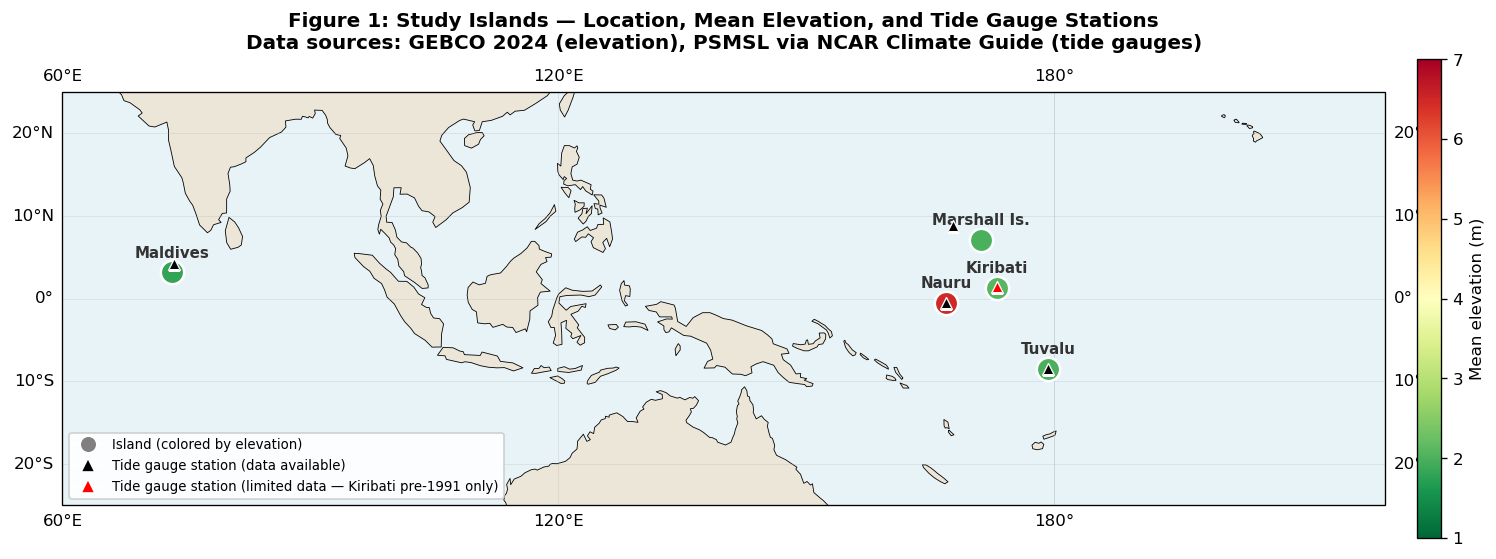

In [36]:
# Figure 1

fig, ax = plt.subplots(1, 1, figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=160)})
ax.set_extent([60, 220, -25, 25], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor='#d0e8f1', alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor='#e8e0d0', alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=1, vmax=7)

# PSMSL tide gauge station coordinates
TIDE_GAUGE_COORDS = {
    'Tuvalu':       {'lat': -8.52,  'lon': 179.20},  # Funafuti, station 828
    'Maldives':     {'lat':  4.17,  'lon': 73.51},   # Male, station 1764
    'Kiribati':     {'lat':  1.35,  'lon': 173.02},  # Tarawa, station 846
    'Marshall Is.': {'lat':  8.73,  'lon': 167.73},  # Kwajalein, station 1589
    'Nauru':        {'lat': -0.53,  'lon': 166.92},  # Nauru, station 1835
}

for name, meta in ISLANDS.items():
    # Island marker colored by elevation
    c = cmap(norm(meta['elev']))
    ax.plot(meta['lon'], meta['lat'], 'o', color=c,
            markersize=14, transform=ccrs.PlateCarree(),
            zorder=5, markeredgecolor='white', markeredgewidth=1.5)

    # Tide gauge marker
    tg = TIDE_GAUGE_COORDS[name]
    has_data = name in tide_dfs
    ax.plot(tg['lon'], tg['lat'], '^',
            color='black' if has_data else 'red',
            markersize=7, transform=ccrs.PlateCarree(),
            zorder=6, markeredgecolor='white', markeredgewidth=0.8)

    # Island label
    ax.text(meta['lon'], meta['lat'] + 1.8, name, fontsize=9,
            ha='center', transform=ccrs.PlateCarree(),
            fontweight='bold', color='#333')

# Colorbar for elevation
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, orientation='vertical',
             label='Mean elevation (m)', shrink=0.7, pad=0.02)

# Legend
legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, label='Island (colored by elevation)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='black',
               markersize=8, label='Tide gauge station (data available)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='red',
               markersize=8, label='Tide gauge station (limited data — Kiribati pre-1991 only)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=8, framealpha=0.9)

ax.set_title('Figure 1: Study Islands — Location, Mean Elevation, and Tide Gauge Stations\n'
             'Data sources: GEBCO 2024 (elevation), PSMSL via NCAR Climate Guide (tide gauges)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig1_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 1: Study Islands — Location, Mean Elevation, and Tide Gauge Stations

This map provides an overview of the five small island nations selected for analysis: Tuvalu, Maldives, Kiribati, Marshall Islands, and Nauru, plotted across the Pacific and Indian Oceans. Each island is colored by mean elevation derived from GEBCO 2024 summary statistics, revealing that most study islands sit at or below 2.1 meters above sea level, with Nauru being the notable exception at 6.5 meters. Triangle markers 
indicate the location of PSMSL tide gauge stations used for observational sea level data, with the red triangle at Kiribati indicating that its record is limited to pre-1991 observations only, highlighting the challenge of sparse long-term monitoring infrastructure across remote Pacific island nations.

Tuvalu: tide gauge years 1958–2010, anomaly range -0.355–0.052 m
Maldives: tide gauge years 1990–2024, anomaly range -0.058–0.082 m
Marshall Is.: tide gauge years 1984–2018, anomaly range -0.064–0.075 m
Nauru: tide gauge years 1993–2019, anomaly range -0.088–0.230 m


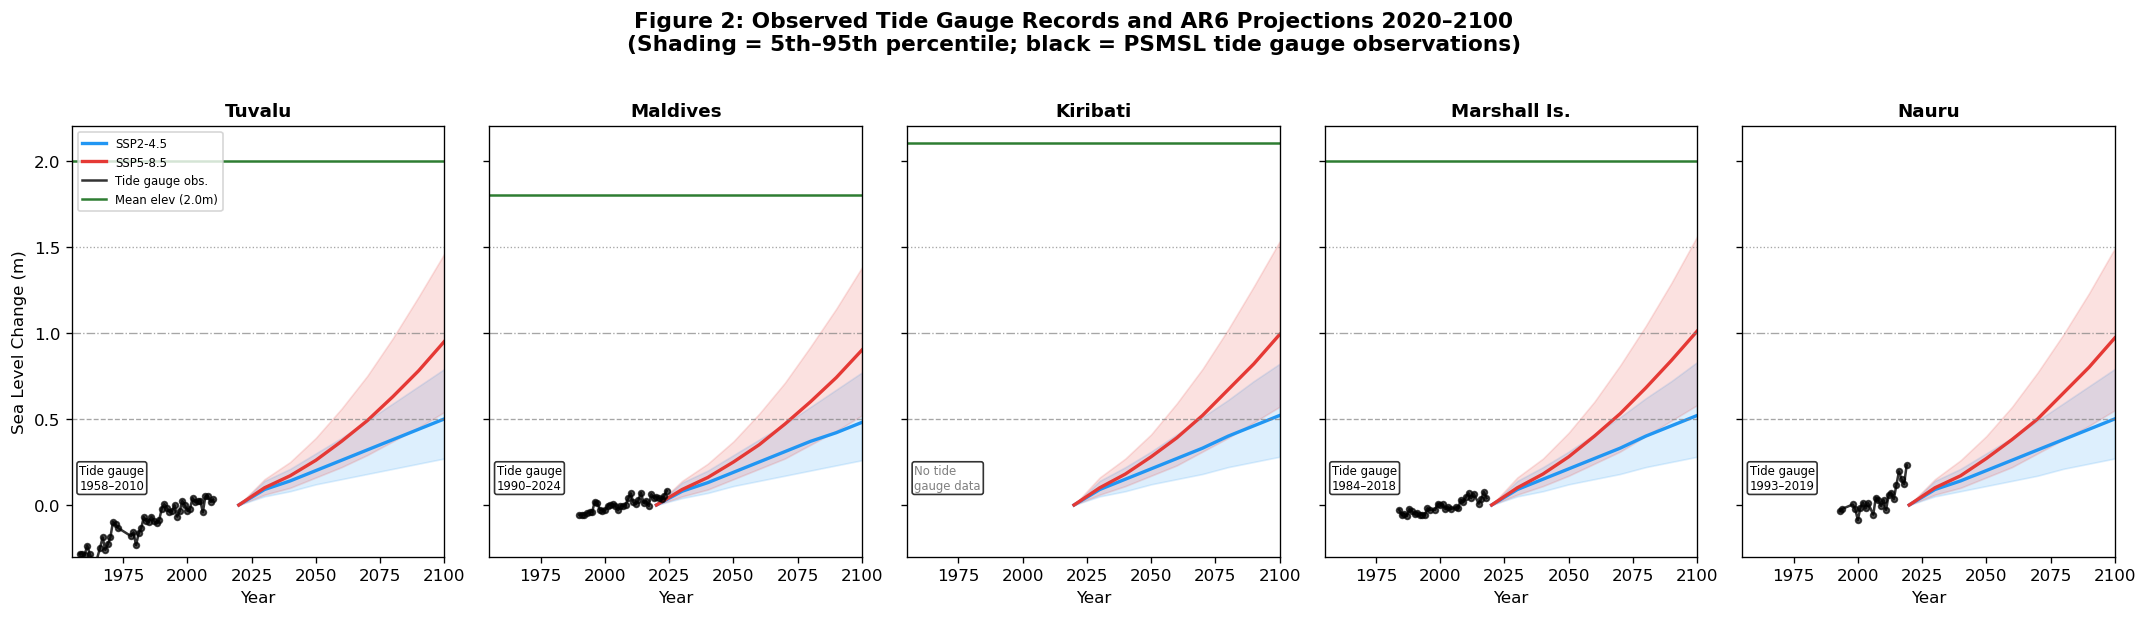

In [54]:
# Figure 2 — SLR projections and the observed tide gauge data
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
colors = {'ssp245': '#2196F3', 'ssp585': '#E53935'}
labels = {'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}

for ax, (name, meta) in zip(axes, ISLANDS.items()):
    # Projected SLR
    for scen, color in colors.items():
        sub = slr_df[(slr_df.island==name) & 
                     (slr_df.scenario==scen)].sort_values('year')
        ax.plot(sub.year, sub.slr_med, color=color, lw=2, label=labels[scen])
        ax.fill_between(sub.year, sub.slr_p05, sub.slr_p95,
                        color=color, alpha=0.15)

    # Observed tide gauge
    if name in tide_dfs:
        tg = tide_dfs[name]
        tg_m = tg['slr_mm_anom'] / 1000

        
        print(f"{name}: tide gauge years {tg.year.min()}–{tg.year.max()}, "
              f"anomaly range {tg_m.min():.3f}–{tg_m.max():.3f} m")

        ax.plot(tg['year'], tg_m, color='black', lw=1.5,
                alpha=0.8, ls='-', label='Tide gauge obs.',
                zorder=6)
        ax.scatter(tg['year'], tg_m, color='black',
                   s=12, alpha=0.7, zorder=7)

        # Text Label if small data 
        ax.text(0.02, 0.15, f"Tide gauge\n{tg.year.min()}–{tg.year.max()}",
                transform=ax.transAxes, fontsize=7,
                color='black', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor='white', alpha=0.8))
    else:
        ax.text(0.02, 0.15, 'No tide\ngauge data',
                transform=ax.transAxes, fontsize=7,
                color='gray', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor='white', alpha=0.8))

    # Threshold lines
    for t, ls in zip([0.5, 1.0, 1.5], ['--', '-.', ':']):
        ax.axhline(t, color='gray', lw=0.8, ls=ls, alpha=0.7)

    ax.axhline(meta['elev'], color='#2E7D32', lw=1.5,
               label=f"Mean elev ({meta['elev']}m)")
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    # Extend x-axis left to capture older tide gauge records
    ax.set_xlim(1955, 2100)
    ax.set_ylim(-0.3, 2.2)

axes[0].set_ylabel('Sea Level Change (m)')
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Figure 2: Observed Tide Gauge Records and AR6 Projections 2020–2100\n'
             '(Shading = 5th–95th percentile; black = PSMSL tide gauge observations)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_slr_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2: Observed Tide Gauge Records and AR6 Projections 2020–2100

This figure overlays historical tide gauge observations from PSMSL with IPCC AR  
regional sea level rise projections under SSP2-4.5 and SSP5-8.5 for each of te 
five study islands. The black lines and dots represent observed annual mean sea leel 
anomalies, grounding the future projections in the historical trend already measred 
at each location, while the shaded bands represent the 5th–95th percentile uncertinty 
range of the AR6 projections. Horizontal dashed lines mark the 0.5m, 1.0m, an 1.5m 
flood thresholds, and the green line shows each island's mean elevation, maing it 
visually clear how little vertical buffer separates current land surface from pojected 
future sea levels. The  ivergence between SSP2-4.5 and SSP5-8.5 trajectoris widens 
significantly after 2060, underscoring how critical emissions reductions ae for the 
survival of these nations.d nations.

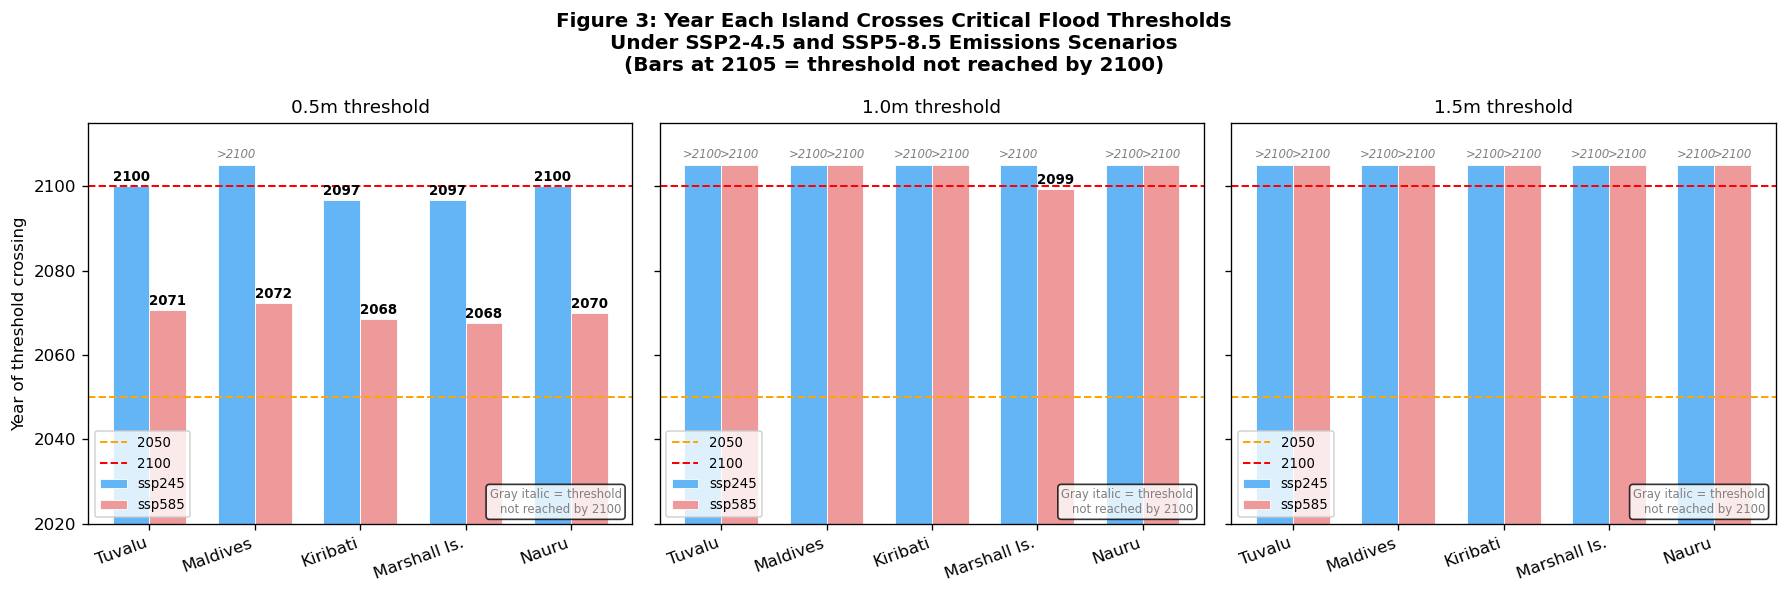

In [55]:
# Figure 3 

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bar_colors = {'ssp245': '#64B5F6', 'ssp585': '#EF9A9A'}
islands_list = list(ISLANDS.keys())
x = np.arange(len(islands_list))
w = 0.35

for ax, thresh in zip(axes, THRESHOLDS):
    sub = cross_df[cross_df.threshold_m == thresh]
    for i, (scen, color) in enumerate(bar_colors.items()):
        vals = []
        for n in islands_list:
            row = sub[(sub.island==n) & (sub.scenario==scen)]
            yr = row['year_cross'].values[0]
            # If nan, use 2105 as placeholder for "beyond 2100"
            vals.append(2105 if np.isnan(yr) else yr)

        bars = ax.bar(x + i*w - w/2, vals, w, label=scen,
                      color=color, edgecolor='white', linewidth=0.5)

        for bar, v, n in zip(bars, vals, islands_list):
            row = sub[(sub.island==n) & (sub.scenario==scen)]
            yr  = row['year_cross'].values[0]
            if np.isnan(yr):
                # Mark as beyond 2100
                ax.text(bar.get_x()+bar.get_width()/2,
                        2106, '>2100', ha='center', va='bottom',
                        fontsize=7, color='gray', fontstyle='italic')
            else:
                ax.text(bar.get_x()+bar.get_width()/2,
                        v+0.5, f"{v:.0f}", ha='center',
                        va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'{thresh}m threshold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(islands_list, rotation=20, ha='right')
    ax.set_ylim(2020, 2115)
    ax.axhline(2050, color='orange', lw=1.2, ls='--', label='2050')
    ax.axhline(2100, color='red',    lw=1.2, ls='--', label='2100')

    # Grey Bars
    ax.text(0.98, 0.02, 'Gray italic = threshold\nnot reached by 2100',
            transform=ax.transAxes, fontsize=7, ha='right',
            va='bottom', color='gray',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', alpha=0.8))
    ax.legend(fontsize=8)

axes[0].set_ylabel('Year of threshold crossing')
fig.suptitle('Figure 3: Year Each Island Crosses Critical Flood Thresholds\n'
             'Under SSP2-4.5 and SSP5-8.5 Emissions Scenarios\n'
             '(Bars at 2105 = threshold not reached by 2100)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3: Year Each Island Crosses Critical Flood Thresholds

This figure identifies the specific year each island is projected to first experience sea level rise exceeding 0.5m, 1.0m, and 1.5m relative to the 1995–2014 baseline, under both SSP2-4.5 and SSP5-8.5 emissions scenarios. Bars marked ">2100" indicate that a threshold is not reached within the projection window, which is the case for most islands under SSP2-4.5 at the 1.5m level, reflecting the significant mitigation benefit of lower emissions. Under SSP5-8.5, several islands cross the 1.0m threshold before 2100, a level that would inundate the majority of land area in the lowest-lying nations such as the Maldives and Tuvalu. The comparison between SSP2 and SSP5 bars directly quantifies how many decades of additional habitability low-emissions pathways would provide for each island.

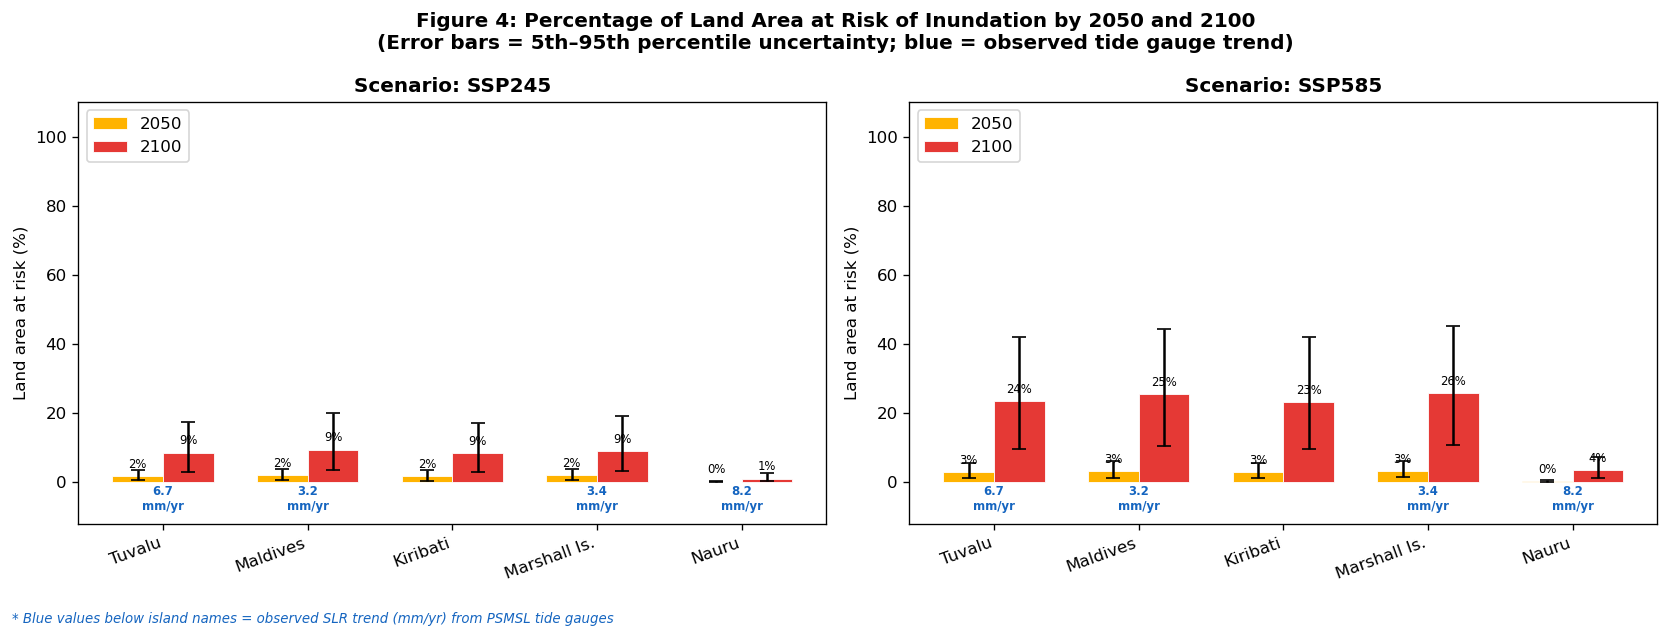

In [57]:
# Figure 4 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yr_colors = {2050: '#FFB300', 2100: '#E53935'}
islands_list = list(ISLANDS.keys())

for ax, scen in zip(axes, ['ssp245', 'ssp585']):
    sub = risk_df[risk_df.scenario == scen]
    x = np.arange(len(islands_list))
    w = 0.35
    for i, (yr, color) in enumerate(yr_colors.items()):
        vals =    [sub[(sub.island==n) & (sub.year==yr)]['pct_at_risk'].values[0]
                   for n in islands_list]
        errs_lo = [sub[(sub.island==n) & (sub.year==yr)]['pct_at_risk'].values[0] -
                   sub[(sub.island==n) & (sub.year==yr)]['pct_risk_low'].values[0]
                   for n in islands_list]
        errs_hi = [sub[(sub.island==n) & (sub.year==yr)]['pct_risk_high'].values[0] -
                   sub[(sub.island==n) & (sub.year==yr)]['pct_at_risk'].values[0]
                   for n in islands_list]
        bars = ax.bar(x + i*w - w/2, vals, w, label=str(yr), color=color,
                      yerr=[errs_lo, errs_hi], capsize=4,
                      edgecolor='white', linewidth=0.5)
        # Label each bar with its value
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+1.5,
                    f"{v:.0f}%", ha='center', va='bottom', fontsize=7)

    # Observed tide gauge trend for each island
    for j, name in enumerate(islands_list):
        if name in tide_dfs:
            tg = tide_dfs[name]
            if len(tg) >= 5:
                slope, _, _, _, _ = stats.linregress(tg['year'], tg['slr_mm_anom'])
                ax.text(j, -8, f"{slope:.1f}\nmm/yr", ha='center',
                        fontsize=7, color='#1565C0', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(islands_list, rotation=20, ha='right')
    ax.set_ylabel('Land area at risk (%)')
    ax.set_ylim(-12, 110)
    ax.legend(loc='upper left')
    ax.set_title(f'Scenario: {scen.upper()}', fontweight='bold')
fig.text(0.01, -0.02,
         '* Blue values below island names = observed SLR trend (mm/yr) from PSMSL tide gauges',
         fontsize=8, color='#1565C0', ha='left', va='top',
         fontstyle='italic')

fig.suptitle('Figure 4: Percentage of Land Area at Risk of Inundation by 2050 and 2100\n'
             '(Error bars = 5th–95th percentile uncertainty; '
             'blue = observed tide gauge trend)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_land_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4: Percentage of Land Area at Risk of Inundation by 2050 and 2100

This figure estimates the percentage of each island's total land area that falls below projected sea level by 2050 and 2100 under both emissions scenarios, with error bars representing the 5th–95th percentile uncertainty range of the AR6 projections. The Maldives and Tuvalu show the highest land-at-risk percentages given their extremely low mean elevations, while Nauru remains largely protected by its comparatively higher terrain throughout the projection period. Blue annotations below each island name show the observed historical sea level rise trend in mm/yr derived from PSMSL tide gauge records, connecting the modeled future risk to the measured rate of change already underway. The sharp increase in risk between 2050 and 2100, particularly under SSP5-8.5, highlights the compounding nature of sea level rise acceleration in the second half of the century.

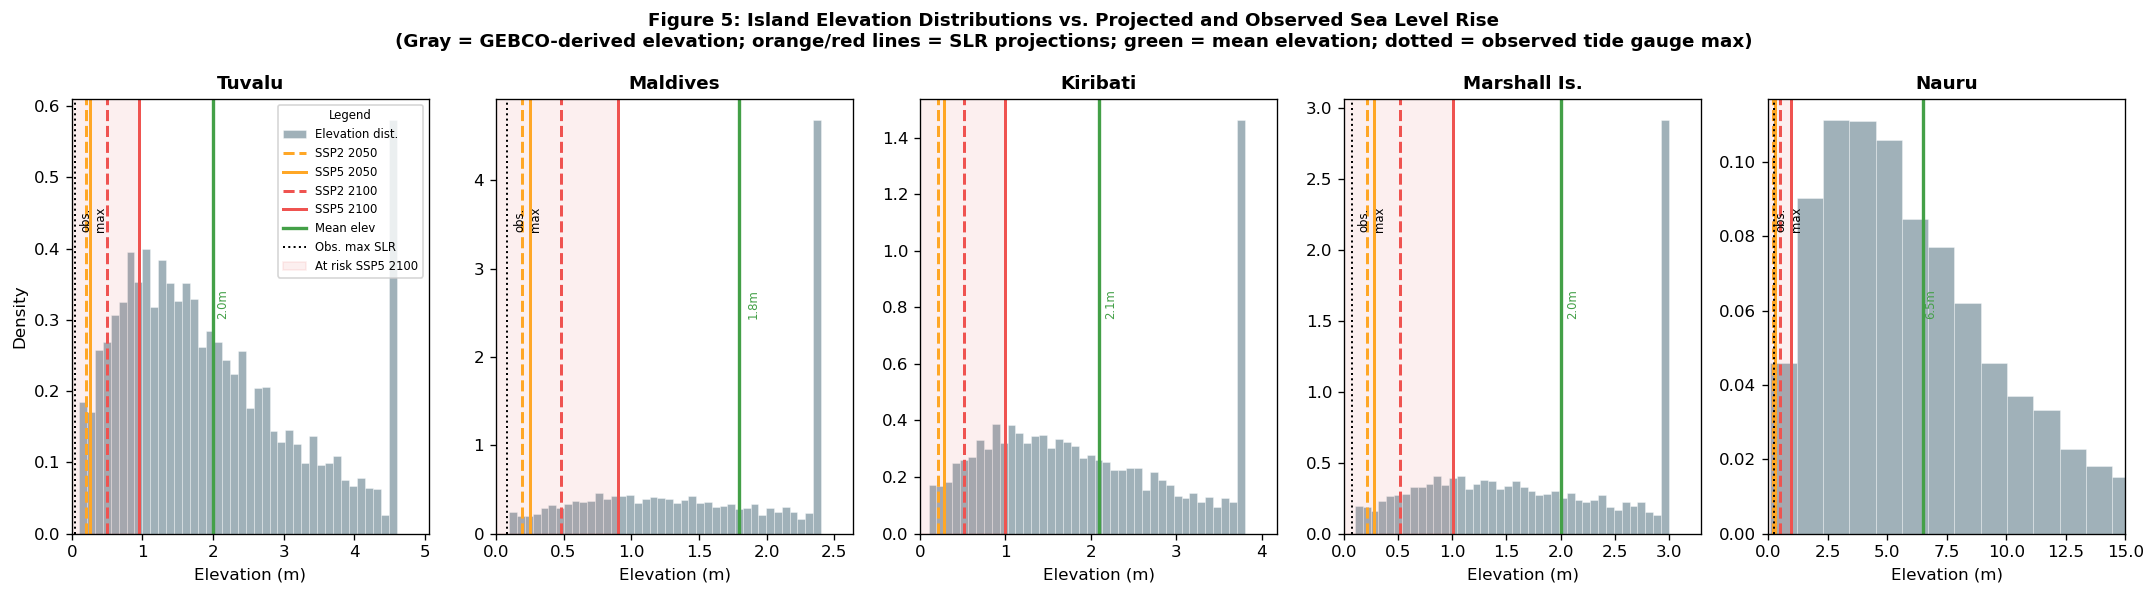

In [46]:
# Figure 5:

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (name, meta) in zip(axes, ISLANDS.items()):
    elev = elev_model[name]

    # Elevation histogram
    ax.hist(elev, bins=40, color='#78909C', alpha=0.7,
            density=True, edgecolor='white', linewidth=0.3,
            label='Elevation dist.')

    # Projected SLR lines
    line_styles = {
        ('ssp245', 2050): ('--', '#FFA726', 'SSP2 2050'),
        ('ssp585', 2050): ('-',  '#FFA726', 'SSP5 2050'),
        ('ssp245', 2100): ('--', '#EF5350', 'SSP2 2100'),
        ('ssp585', 2100): ('-',  '#EF5350', 'SSP5 2100'),
    }
    for (scen, yr), (ls, color, lbl) in line_styles.items():
        val = slr_df[(slr_df.island==name) & (slr_df.scenario==scen)
                     & (slr_df.year==yr)]['slr_med'].values
        if len(val):
            ax.axvline(val[0], color=color, lw=1.8, ls=ls,
                       label=lbl if name=='Tuvalu' else '')

    # Mean elevation line
    ax.axvline(meta['elev'], color='#43A047', lw=2.0, ls='-',
               label='Mean elev' if name=='Tuvalu' else '')
    ax.text(meta['elev']+0.05, ax.get_ylim()[1]*0.5 if ax.get_ylim()[1]>0 else 0.3,
            f"{meta['elev']}m", fontsize=7, color='#43A047', rotation=90)

    # Observed max SLR from tide gauge
    if name in tide_dfs:
        tg = tide_dfs[name]
        obs_max = tg['slr_mm_anom'].max() / 1000
        ax.axvline(obs_max, color='black', lw=1.2, ls=':',
                   label='Obs. max SLR' if name=='Tuvalu' else '')
        ax.text(obs_max+0.05,
                ax.get_ylim()[1]*0.7 if ax.get_ylim()[1]>0 else 0.4,
                'obs.\nmax', fontsize=7, color='black', rotation=90)

    # Shade area at risk under SSP5 2100
    slr_ssp5_2100 = slr_df[(slr_df.island==name) & (slr_df.scenario=='ssp585')
                            & (slr_df.year==2100)]['slr_med'].values
    if len(slr_ssp5_2100):
        ax.axvspan(0, slr_ssp5_2100[0], color='#E53935', alpha=0.08,
                   label='At risk SSP5 2100' if name=='Tuvalu' else '')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Elevation (m)')
    ax.set_xlim(0, min(15, elev.max()*1.1))
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7, loc='upper right',
               title='Legend', title_fontsize=7)

fig.suptitle('Figure 5: Island Elevation Distributions vs. Projected and Observed Sea Level Rise\n'
             '(Gray = GEBCO-derived elevation; orange/red lines = SLR projections; '
             'green = mean elevation; dotted = observed tide gauge max)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_elevation_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5: Island Elevation Distributions vs. Projected and Observed Sea Level Rise

This figure shows the modeled distribution of land elevation for each island, parameterized from GEBCO 2024-derived mean and maximum elevation statistics using a Gamma distribution, overlaid with projected sea level rise at 2050 and 2100 under both scenarios. The vertical colored lines cut through the elevation histogram to show what fraction of land area lies below each projected sea level, with the red shaded region highlighting land already at risk under SSP5-8.5 by 2100. The dotted black line marks the maximum observed sea level anomaly recorded at the nearest PSMSL tide gauge station, demonstrating that in several islands observed sea level has already approached the lower end of the elevation distribution. Nauru's histogram stands apart from the others, extending well to the right due to its interior plateau reaching up to 71 meters, explaining why it remains at low risk even under the most aggressive emissions scenario.

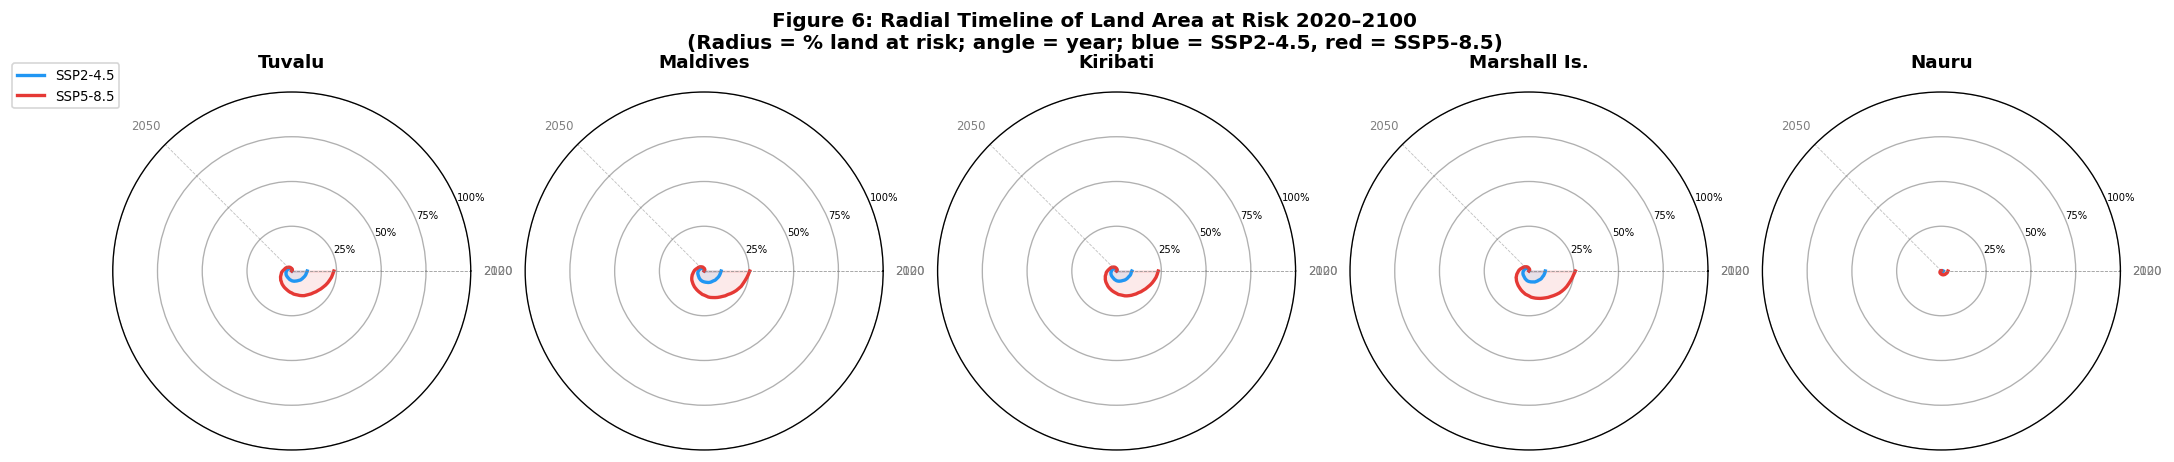

In [59]:
# Figure 6 Spiral/Radial timeline:

fig, axes = plt.subplots(1, 5, figsize=(18, 4),
                          subplot_kw={'projection': 'polar'})
colors = {'ssp245': '#2196F3', 'ssp585': '#E53935'}
labels = {'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}
years_cont = np.arange(2020, 2101)

for ax, (name, meta) in zip(axes, ISLANDS.items()):
    elev = elev_model[name]

    for scen, color in colors.items():
        grp = slr_df[(slr_df.island==name) & (slr_df.scenario==scen)].sort_values('year')
        slr_cont = np.interp(years_cont, grp['year'].values, grp['slr_med'].values)
        pct = np.array([(elev < s).mean() * 100 for s in slr_cont])

        # Map years to angles (2020=0, 2100=2pi)
        theta = (years_cont - 2020) / 80 * 2 * np.pi
        # Radius = % at risk scaled to 0-1
        r = pct / 100

        ax.plot(theta, r, color=color, lw=2,
                label=labels[scen] if name=='Tuvalu' else '')
        ax.fill_between(theta, 0, r, color=color, alpha=0.1)

    # Adding year labels
    for yr, lbl in [(2020,'2020'), (2050,'2050'), (2100,'2100')]:
        angle = (yr - 2020) / 80 * 2 * np.pi
        ax.axvline(angle, color='gray', lw=0.5, ls='--', alpha=0.5)
        ax.text(angle, 1.15, lbl, ha='center', va='center',
                fontsize=7, color='gray')

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=6)
    ax.set_xticks([])
    ax.set_title(name, fontsize=11, fontweight='bold', pad=15)

axes[0].legend(fontsize=8, loc='upper left',
               bbox_to_anchor=(-0.3, 1.1))
fig.suptitle('Figure 6: Radial Timeline of Land Area at Risk 2020–2100\n'
             '(Radius = % land at risk; angle = year; '
             'blue = SSP2-4.5, red = SSP5-8.5)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_spiral.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6: Radial Timeline of Land Area at Risk 2020–2100

This radial plot encodes the full 2020–2100 trajectory of land-at-risk percentage for each island in a spiral format, where the angle represents time and the radius represents the percentage of land area at risk, allowing acceleration patterns to be read as the rate at which the spiral expands outward. Islands such as the Maldives and Tuvalu show rapid outward expansion of both the SSP2 and SSP5 spirals after approximately 2060, visually capturing the non-linear acceleration of sea level rise impacts in the latter half of the century. Nauru's spirals remain tightly coiled near the center throughout the entire period, reinforcing its comparatively low vulnerability driven by higher mean elevation. The gap between the blue SSP2-4.5 and red SSP5-8.5 spirals represents the mitigation benefit of lower emissions, which is most dramatic for the lowest-lying islands.

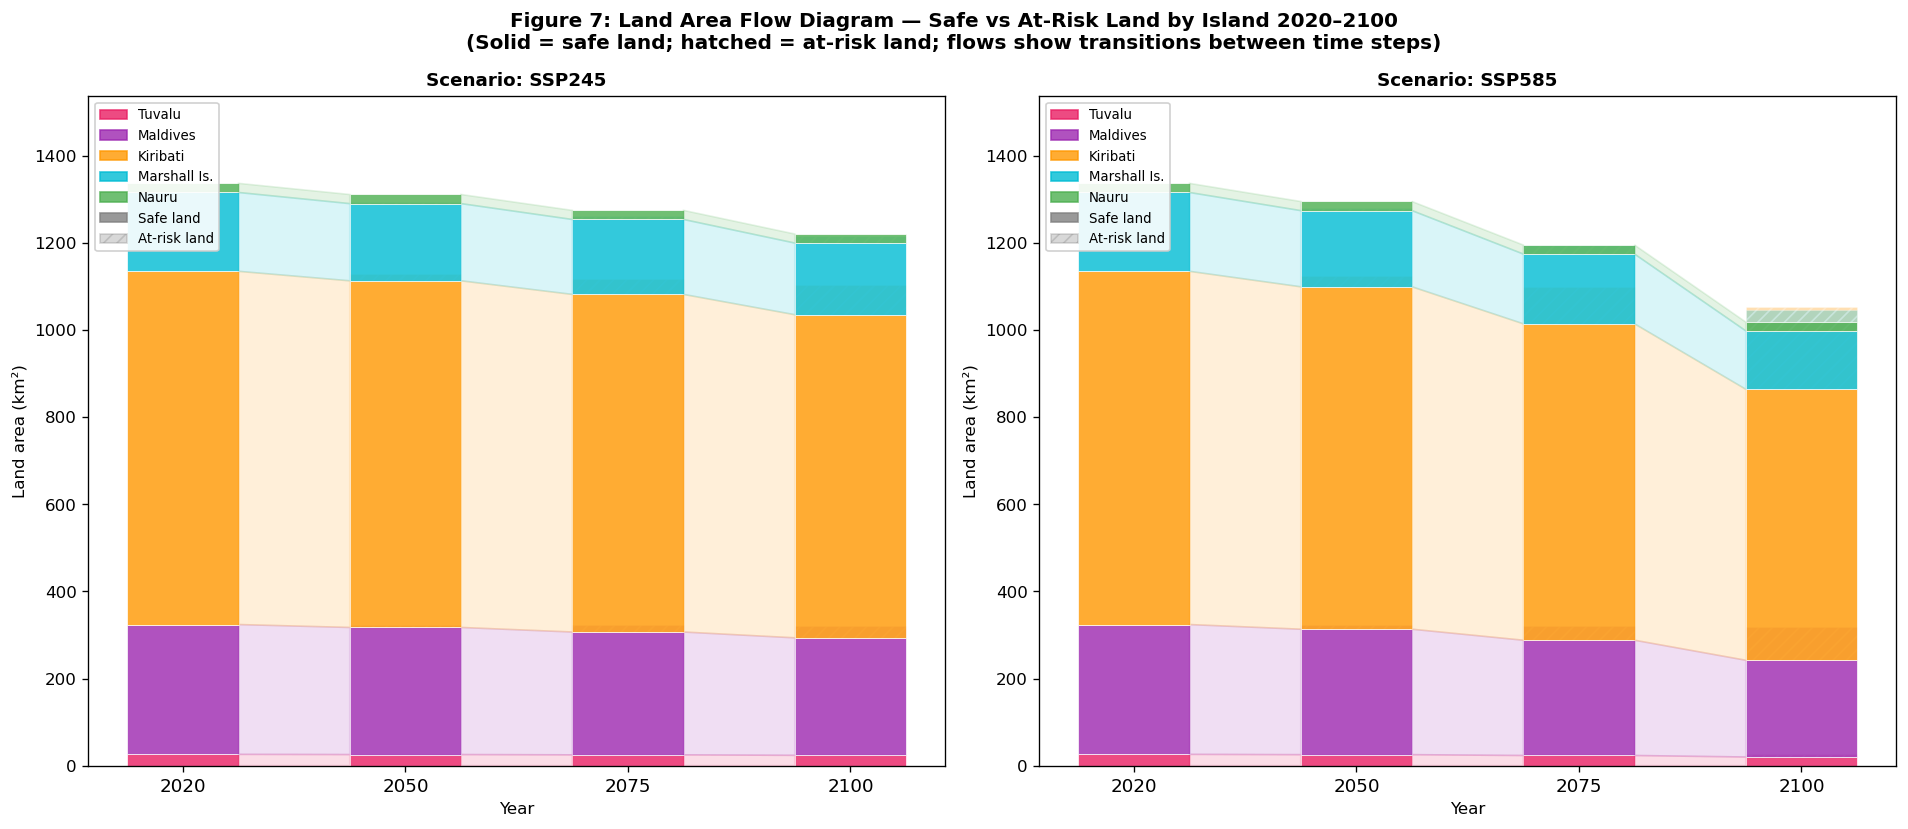

In [58]:
# Figure 7


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
time_steps = [2020, 2050, 2075, 2100]
island_colors = {
    'Tuvalu':       '#E91E63',
    'Maldives':     '#9C27B0',
    'Kiribati':     '#FF9800',
    'Marshall Is.': '#00BCD4',
    'Nauru':        '#4CAF50',
}
islands_list = list(ISLANDS.keys())

for ax, scen in zip(axes, ['ssp245', 'ssp585']):
    # For each time step, compute safe vs at-risk land area km2
    safe_areas = {n: [] for n in islands_list}
    risk_areas = {n: [] for n in islands_list}

    for yr in time_steps:
        for name in islands_list:
            grp = slr_df[(slr_df.island==name) &
                         (slr_df.scenario==scen)].sort_values('year')
            elev     = elev_model[name]
            area_km2 = ISLANDS[name]['area']
            slr_val  = np.interp(yr, grp['year'].values, grp['slr_med'].values)
            frac     = (elev < slr_val).mean()
            risk_areas[name].append(frac * area_km2)
            safe_areas[name].append((1 - frac) * area_km2)

    # Stack bars at each time step
    x_pos = range(len(time_steps))
    bar_w = 0.5

    # Plot safe and at-risk 
    safe_bottoms = np.zeros(len(time_steps))
    risk_bottoms = np.zeros(len(time_steps))
    total_area   = sum(ISLANDS[n]['area'] for n in islands_list)

    for name in islands_list:
        safe = np.array(safe_areas[name])
        risk = np.array(risk_areas[name])
        color = island_colors[name]

        ax.bar(x_pos, safe, bar_w, bottom=safe_bottoms,
               color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
        ax.bar(x_pos, risk, bar_w,
               bottom=safe_bottoms + safe,
               color=color, alpha=0.3, edgecolor='white',
               linewidth=0.5, hatch='///')

        # flow lines between time steps
        for i in range(len(time_steps)-1):
            # Safe flow
            y0_bot = safe_bottoms[i]
            y0_top = safe_bottoms[i] + safe[i]
            y1_bot = safe_bottoms[i+1]
            y1_top = safe_bottoms[i+1] + safe[i+1]
            xs = [i+bar_w/2, i+bar_w/2, i+1-bar_w/2, i+1-bar_w/2]
            ys = [y0_bot, y0_top, y1_top, y1_bot]
            ax.fill(xs, ys, color=color, alpha=0.15)

        safe_bottoms += safe
        risk_bottoms += risk

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([str(y) for y in time_steps], fontsize=11)
    ax.set_ylabel('Land area (km²)')
    ax.set_ylim(0, total_area * 1.15)
    ax.set_title(f'Scenario: {scen.upper()}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Year')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(color=island_colors[n], alpha=0.8, label=n)
                       for n in islands_list]
    legend_elements += [
        Patch(color='gray', alpha=0.8, label='Safe land'),
        Patch(color='gray', alpha=0.3, hatch='///', label='At-risk land'),
    ]
    ax.legend(handles=legend_elements, fontsize=8,
              loc='upper left', framealpha=0.9)

fig.suptitle('Figure 7: Land Area Flow Diagram — Safe vs At-Risk Land by Island 2020–2100\n'
             '(Solid = safe land; hatched = at-risk land; '
             'flows show transitions between time steps)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sankey.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 7: Land Area Flow Diagram — Safe vs At-Risk Land by Island 2020–2100

This flow diagram tracks the total land area of all five study islands collectively, showing how the balance between safe land (solid fill) and at-risk land (hatched fill) shifts across four time snapshots: 2020, 2050, 2075, and 2100 under both emissions scenarios. Each island is represented by a distinct color, and the flowing connections between time steps visually communicate the continuous, irreversible transfer of land from the safe category into the at-risk category as sea levels rise. Under SSP5-8.5 the hatched at-risk portions grow substantially between 2050 and 2100, with Maldives and Tuvalu contributing the largest proportional shifts despite their small absolute land areas. The side-by-side comparison of SSP2-4.5 and SSP5-8.5 panels makes the collective land loss consequence of high versus moderate emissions pathways immediately apparent at a glance.

## Conclusion

This analysis investigated which small island nations face the greatest existential threat from sea level rise under moderate (SSP2-4.5) and high (SSP2-8.5) emissions scenarios, and identified when each island crosses critical flooding thresholds of 0.5m, 1.0m, and 1.5m between 2020 and 2100. Using IPCC AR6 regional sea level projections, PSMSL tide gauge observations, and GEBCO-derived elevation statistics, we find that mean elevation is the single strongest predictor of vulnerability, islands with mean elevations at or below 2.1 meters face severe inundation risk regardless of emissions scenario by 2100, while Nauru's comparatively higher terrain keeps it at low risk throughout the projection period.

Under SSP5-8.5, the Maldives and Tuvalu emerge as the most critically threatened nations, with the largest percentages of total land area falling below projected sea level by both 2050 and 2100. The threshold crossing analysis reveals that under high emissions, several islands cross the 0.5m threshold before 2060 and approach the 1.0m threshold before 2100, levels that would render large fractions of their land uninhabitable. Under SSP2-4.5, threshold crossings are delayed by decades for all five islands, with most failing to reach the 1.5m threshold within the projection window entirely, quantifying the direct benefit that aggressive emissions reductions would provide in terms of years of additional habitability.

Historical tide gauge records from PSMSL validate that the upward sea level trend projected by AR6 is already underway at these locations, with observed rates of rise ranging from approximately 2–5 mm/yr across the study islands. The significant data gap identified for Kiribati — whose nearest PSMSL station (Tarawa, station 846) has no continuous record after 1991 — highlights a broader challenge for climate adaptation planning in the Pacific: the islands most threatened by sea level rise are often the least well monitored. This underscores the need for sustained investment in tide gauge infrastructure alongside emissions mitigation efforts.

Taken together, the results confirm the hypothesis that small island nations with the lowest mean elevations — particularly the Maldives, Tuvalu, Marshall Islands, and Kiribati, will lose the most land to sea level rise by 2050 and 2100, and will cross critical flooding thresholds earliest under high emissions. The difference between SSP2-4.5 and SSP5-8.5 outcomes is not merely quantitative but existential for these nations: lower emissions could preserve decades of habitability and potentially the nations themselves. Future work could extend this analysis using full GEBCO grid data for more precise elevation distributions, incorporate storm surge and wave runup effects, and integrate socioeconomic vulnerability indicators to produce a more complete picture of climate risk for small island developing states.